In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [29]:
appli_price_stationery= yf.download("AAPL", start="2010-1-1")
appli_price_stationery.columns=appli_price_stationery.columns.get_level_values(0)
appli_price_stationery.columns

[*********************100%***********************]  1 of 1 completed


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [35]:
train_data,test_data=appli_price_stationery["Close"][:-30].dropna(),appli_price_stationery["Close"][-30:].dropna()

In [36]:
type(train_data)

pandas.core.series.Series

In [38]:
len(train_data)

4124

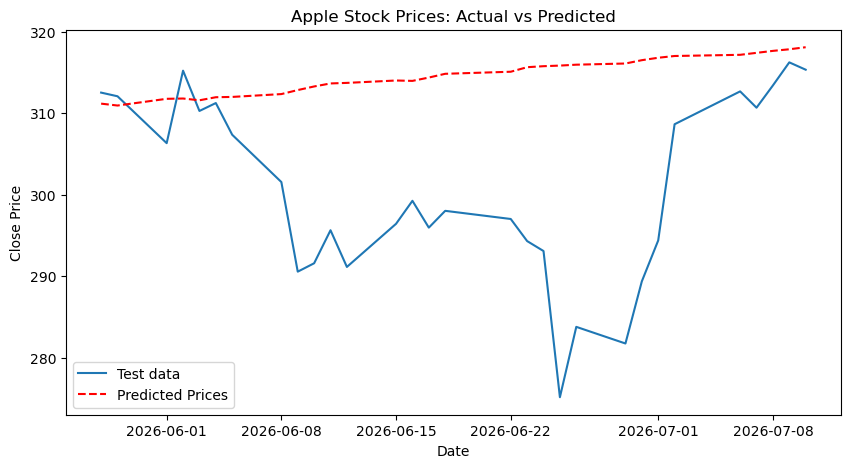

RMSE:  17.98


In [37]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Fit the Autoregressive model (AR) to the training data
model = AutoReg(train_data, lags=30)
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE: ', rmse)

# MA model

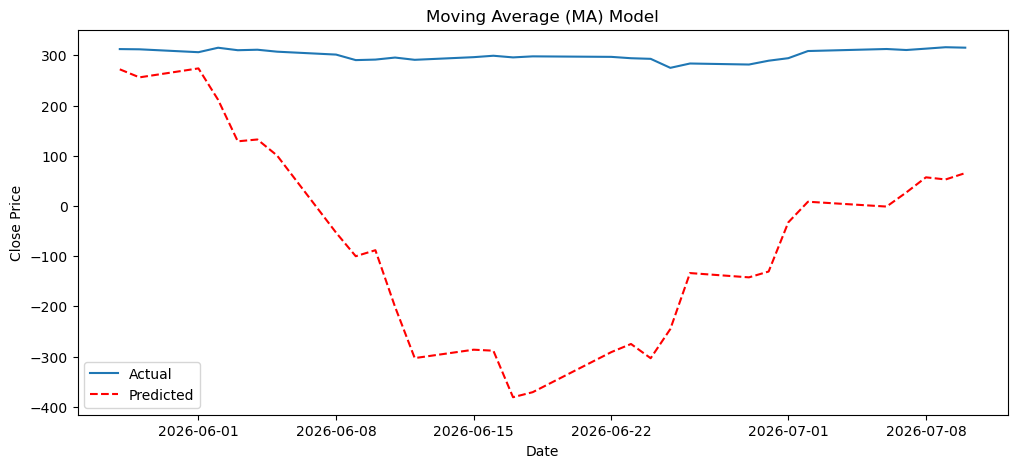

RMSE: 413.88


In [41]:
from statsmodels.tsa.arima.model import ARIMA
# Fit MA(30) model
model = ARIMA(train_data, order=(0, 0, 30))
model_fit = model.fit()

# Forecast next 30 observations
predictions = model_fit.forecast(steps=len(test_data))

# Plot Actual vs Predicted
plt.figure(figsize=(12,5))
plt.plot(test_data.index, test_data, label='Actual')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted')
plt.title("Moving Average (MA) Model")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# RMSE
rmse = np.sqrt(mean_squared_error(test_data, predictions))
print("RMSE:", round(rmse, 2))

# Arima model

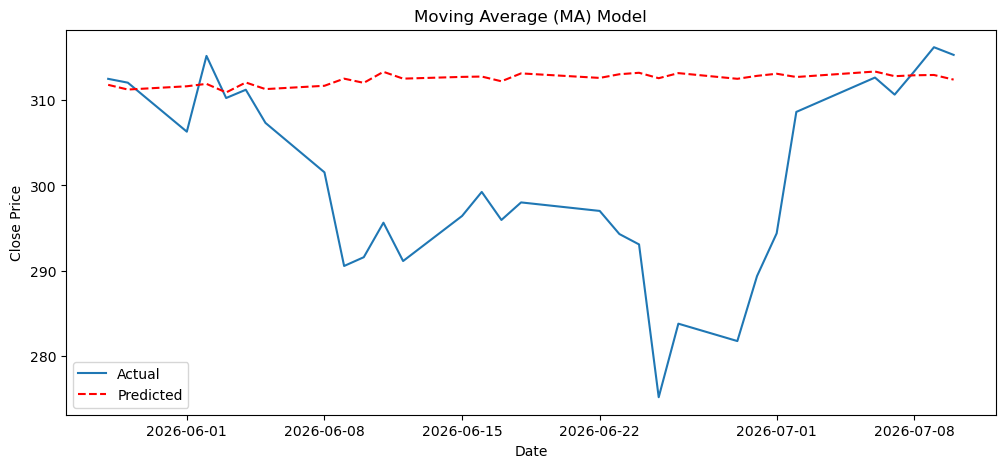

RMSE: 16.26


In [43]:
from statsmodels.tsa.arima.model import ARIMA
# Fit MA(30) model
model = ARIMA(train_data, order=(7, 1, 30))
model_fit = model.fit()

# Forecast next 30 observations
predictions = model_fit.forecast(steps=len(test_data))

# Plot Actual vs Predicted
plt.figure(figsize=(12,5))
plt.plot(test_data.index, test_data, label='Actual')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted')
plt.title("Moving Average (MA) Model")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

# RMSE
rmse = np.sqrt(mean_squared_error(test_data, predictions))
print("RMSE:", round(rmse, 2))

# Sarima model 

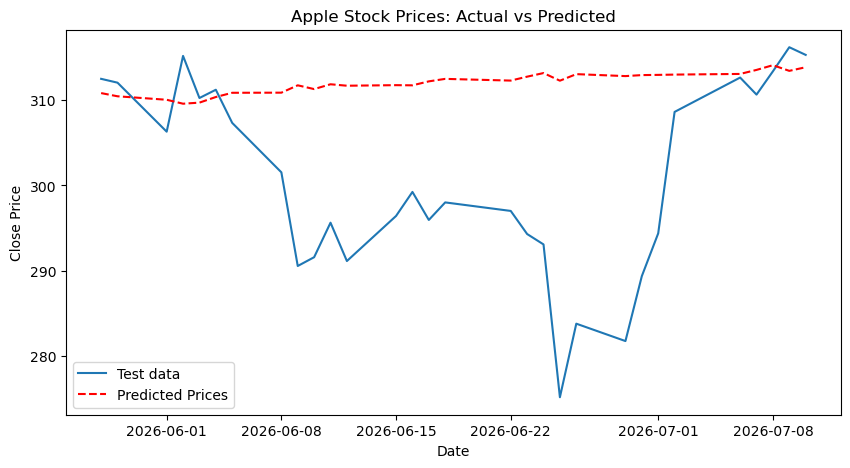

RMSE:  15.99


In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

p, d, q = 7, 1, 7
P, D, Q, s = 1, 1, 1, 45

# Fit the SARIMA model
model = SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, s))
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False)

# Plot the actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Apple Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE: ', rmse)

# Vector Model

In [50]:
tsla_data = yf.download('TSLA', start='2023-01-01')

appli_price_stationery['TSLA_Close'] = tsla_data['Close']
appli_price_stationery['APPL_Close'] = appli_price_stationery['Close'].shift()
appli_price_stationery.dropna(inplace=True)

from statsmodels.tsa.stattools import grangercausalitytests

# perform Granger-Causality test
grangercausalitytests(appli_price_stationery[['APPL_Close', 'TSLA_Close']].dropna(), maxlag=[14])
print()

[*********************100%***********************]  1 of 1 completed


Granger Causality
number of lags (no zero) 14
ssr based F test:         F=9.8049  , p=0.0000  , df_denom=838, df_num=14
ssr based chi2 test:   chi2=142.0192, p=0.0000  , df=14
likelihood ratio test: chi2=131.5197, p=0.0000  , df=14
parameter F test:         F=9.8049  , p=0.0000  , df_denom=838, df_num=14



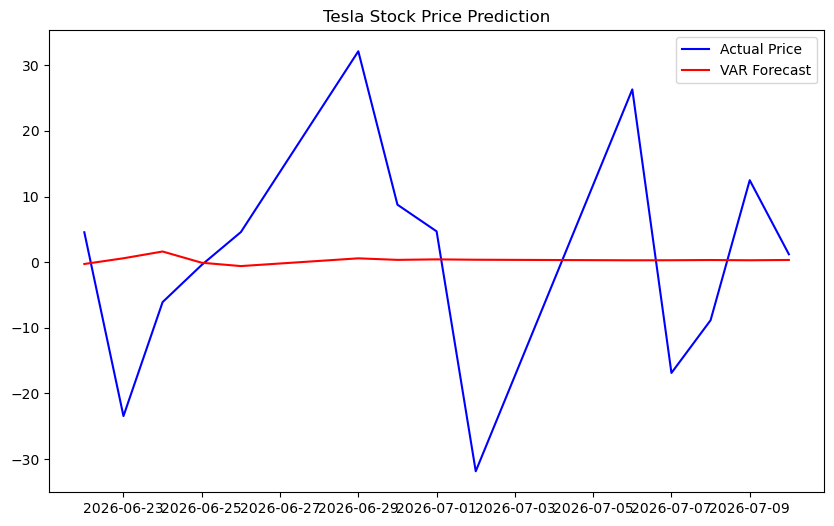

RMSE:  16.94


In [52]:
data = appli_price_stationery[['APPL_Close', 'TSLA_Close']].diff().dropna()
train_data, test_data = data[:-14], data[-14:]

from statsmodels.tsa.api import VAR, VARMAX

# VAR
model = VAR(train_data)
result = model.fit(maxlags=7)
predictions = result.forecast(train_data.values[-result.k_ar:], steps=len(test_data))

predictions = pd.DataFrame(predictions, index=test_data.index, columns=test_data.columns)
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['TSLA_Close'], label='Actual Price', color='blue')
plt.plot(test_data.index, predictions['TSLA_Close'], label='VAR Forecast', color='red')
plt.legend()
plt.title('Tesla Stock Price Prediction')
plt.show()

# evaluating model using RMSE score
rmse = round(np.sqrt(mean_squared_error(test_data['TSLA_Close'], predictions['TSLA_Close'])), 2)
print('RMSE: ', rmse)